# Telecom Customer Churn — Exploratory Data Analysis
**Author:** Yusra Imran Vekriwala | **Dataset:** IBM Telco (Kaggle) | **Tools:** Python, Pandas, Seaborn

**1. Importing necessary libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Loading the dataset**

In [2]:
df = pd.read_csv(WA_Fn-UseC_-Telco-Customer-Churn.csv')

**Basic exploration to understand the data on the surface**

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**3. EDA & DATA CLEANING:**
Since Total charges are string which should logically numerical value, convert it to numeric data type 

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Since there are 10 missing values to handle**

In [8]:
df[df['TotalCharges'].isnull()]['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

In [9]:
#New customer tenure is logically 0 so filling it with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
#Number of customers cu
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
#ratio of customers churn
100*df['Churn'].value_counts()/len(df['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

Text(0.5, 1.0, 'Count of customer churn per category')

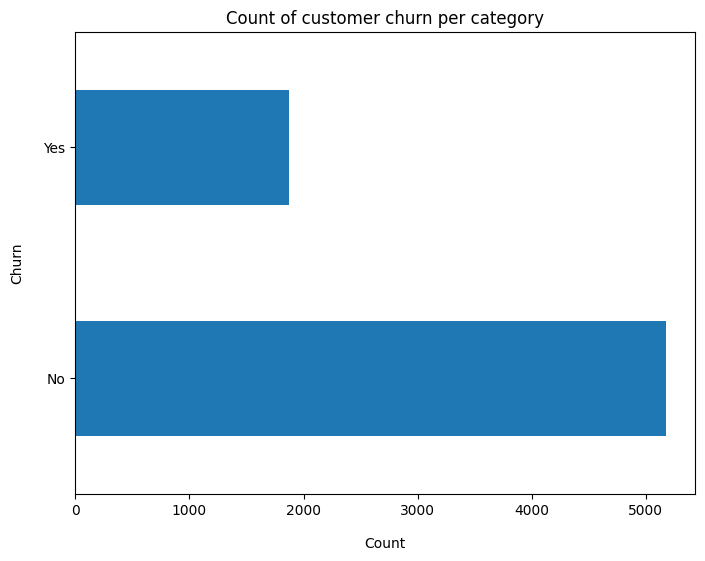

In [13]:
# Data visualization for customer
df['Churn'].value_counts().plot(kind = 'barh', figsize = (8,6))
plt.xlabel("Count", labelpad = 14)
plt.ylabel("Churn", labelpad = 14)
plt.title("Count of customer churn per category")

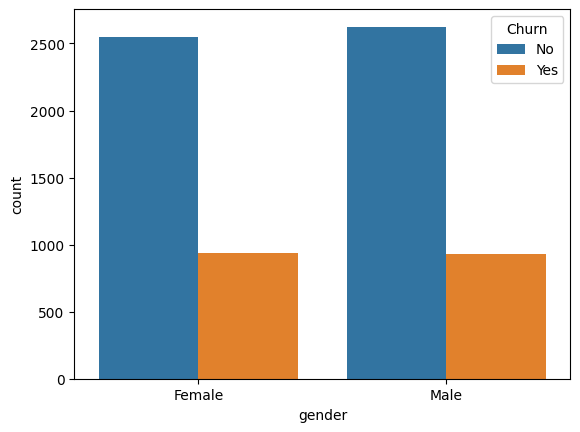

In [14]:
#Gender vs churn
sns.countplot(x = 'gender', hue = 'Churn', data = df)
plt.show()

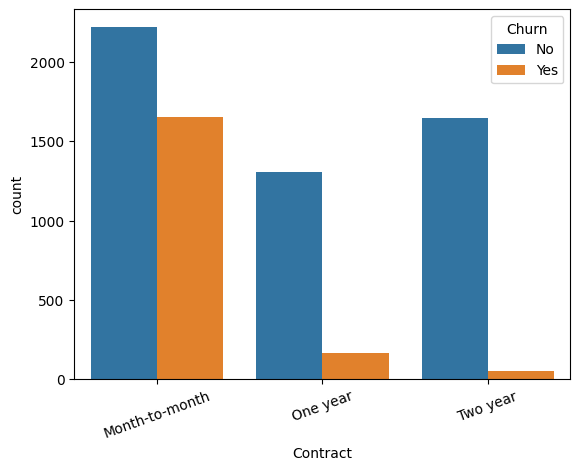

In [15]:
#Contract Type vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.show()

##Expected Insight
##Month-to-month customers usually churn more.
##Long-term contracts reduce churn.

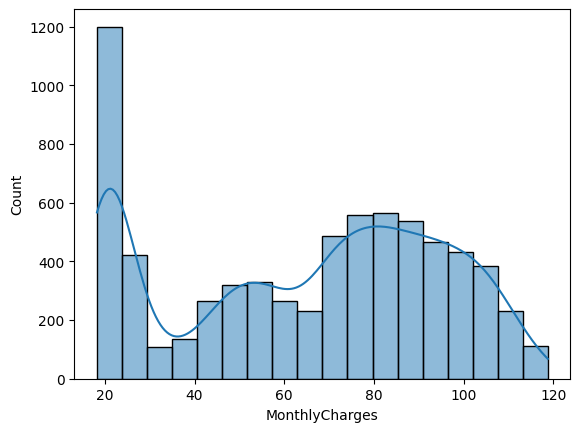

In [16]:
#Monthly Charges Distribution
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

##Insight
##Higher monthly charges may increase churn probability.

In [17]:
# Discretization tenue
bins = [0, 13, 25, 37, 49, 61, 73]
labels = ['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']

df['tenuregroup'] = pd.cut(
    df['tenure'],
    bins = bins,
    labels = labels,
    right = 'false'
)
df['tenuregroup'].value_counts()

tenuregroup
1-12     2284
61-72    1331
13-24     994
49-60     842
25-36     818
37-48     763
Name: count, dtype: int64

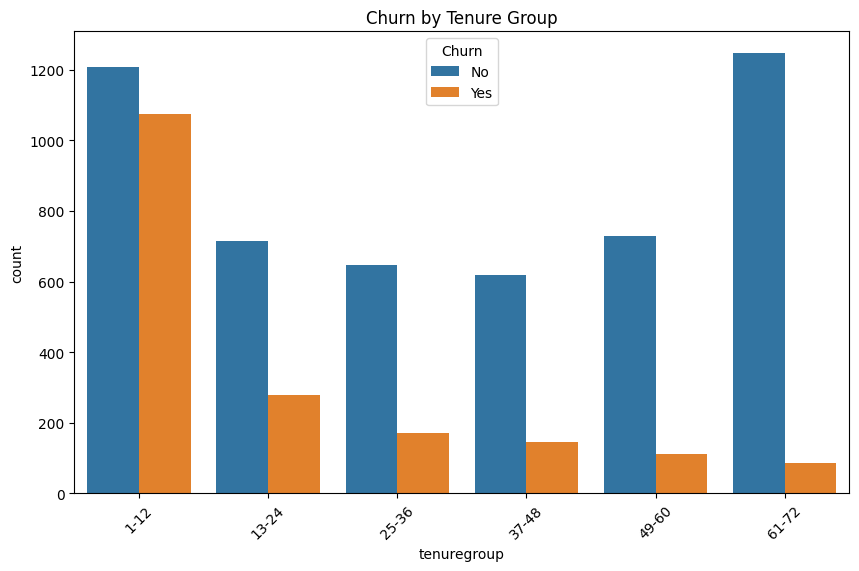

In [18]:
#visualization tenure vs count
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='tenuregroup', hue='Churn')
plt.xticks(rotation=45)
plt.title("Churn by Tenure Group")
plt.show()

##Expected Insight
##Customers with lower tenure often churn more.

In [19]:
#clean the data by dropping columns
df.drop(['customerID', 'tenure'], axis = 1, inplace = True)
df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenuregroup
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,13-24
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,61-72
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1-12
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1-12


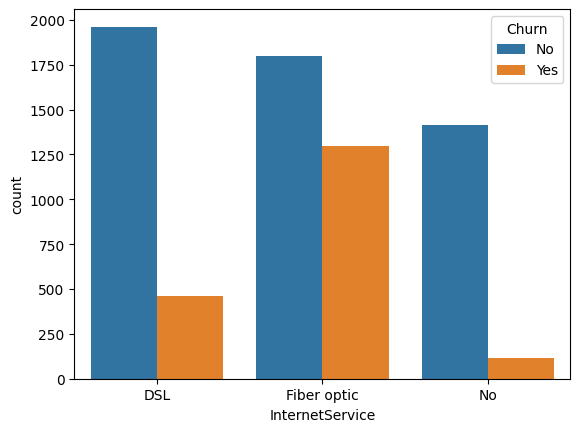

In [20]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

##Fiber optic users may churn more due to higher costs.

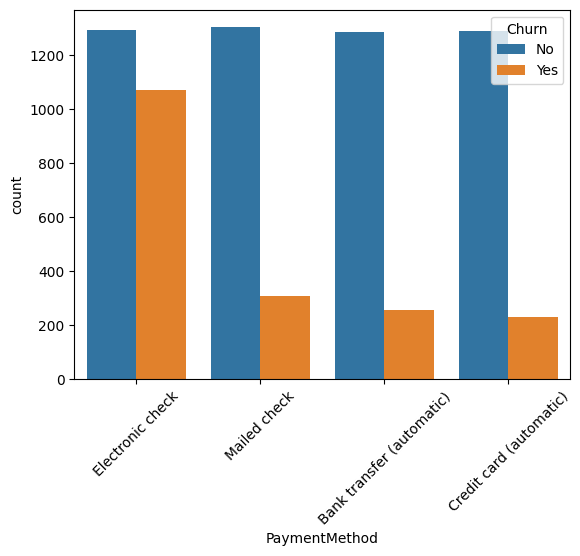

In [21]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

##Electronic check customers often show higher churn.

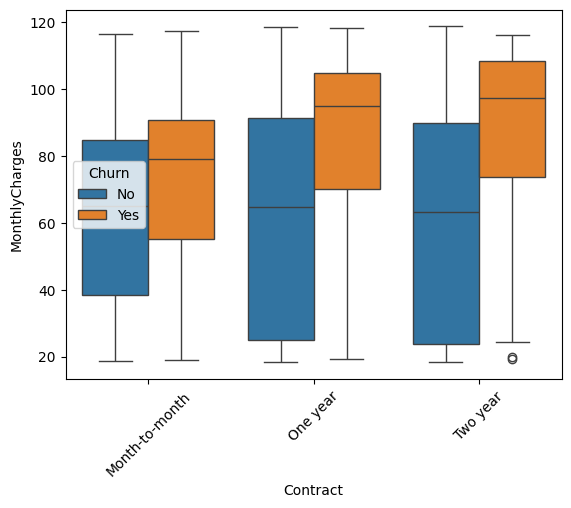

In [22]:
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

In [23]:
df['Churn'] = np.where(df.Churn == 'Yes',1,0)

In [24]:
df_dummies = pd.get_dummies(df, dtype=int)
df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenuregroup_1-12,tenuregroup_13-24,tenuregroup_25-36,tenuregroup_37-48,tenuregroup_49-60,tenuregroup_61-72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


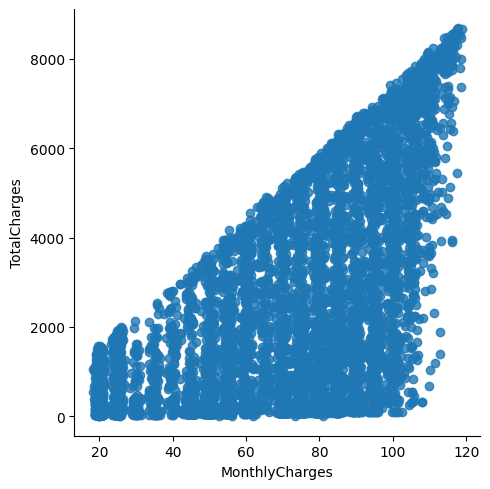

In [25]:
sns.lmplot(data = df_dummies, x = 'MonthlyCharges', y = 'TotalCharges', fit_reg = False)

Total charges increase so as monthly charges

Text(0.5, 1.0, 'Monthly Charges by churn')

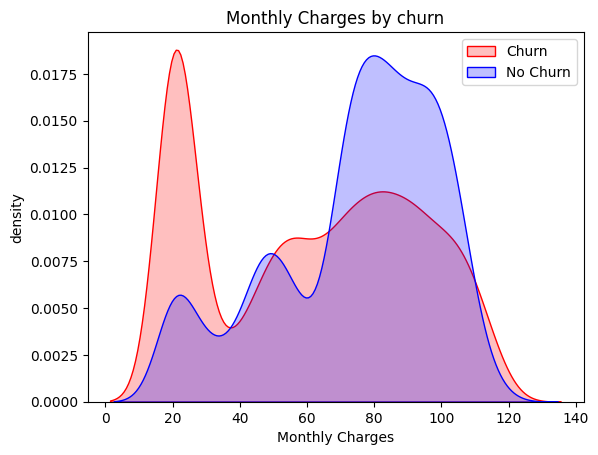

In [26]:
mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies['Churn'] == 0)], color = "red", fill = True)
mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies['Churn'] == 1)], color = "blue", fill = True)
mth.legend(["Churn", "No Churn"], loc = "upper right")
mth.set_xlabel('Monthly Charges')
mth.set_ylabel('density')
mth.set_title('Monthly Charges by churn')

Churn is high when monthly charges are high

Text(0.5, 1.0, 'Monthly Charges by churn')

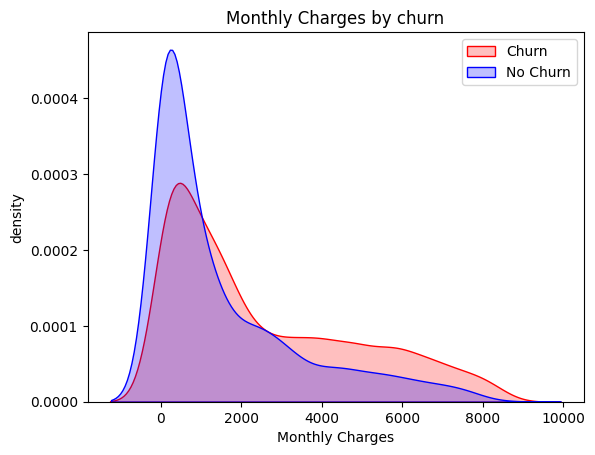

In [27]:
mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies['Churn'] == 0)], color = "red", fill = True)
mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies['Churn'] == 1)], color = "blue", fill = True)
mth.legend(["Churn", "No Churn"], loc = "upper right")
mth.set_xlabel('Monthly Charges')
mth.set_ylabel('density')
mth.set_title('Monthly Charges by churn')

Churn is high when total charges are low

<Axes: >

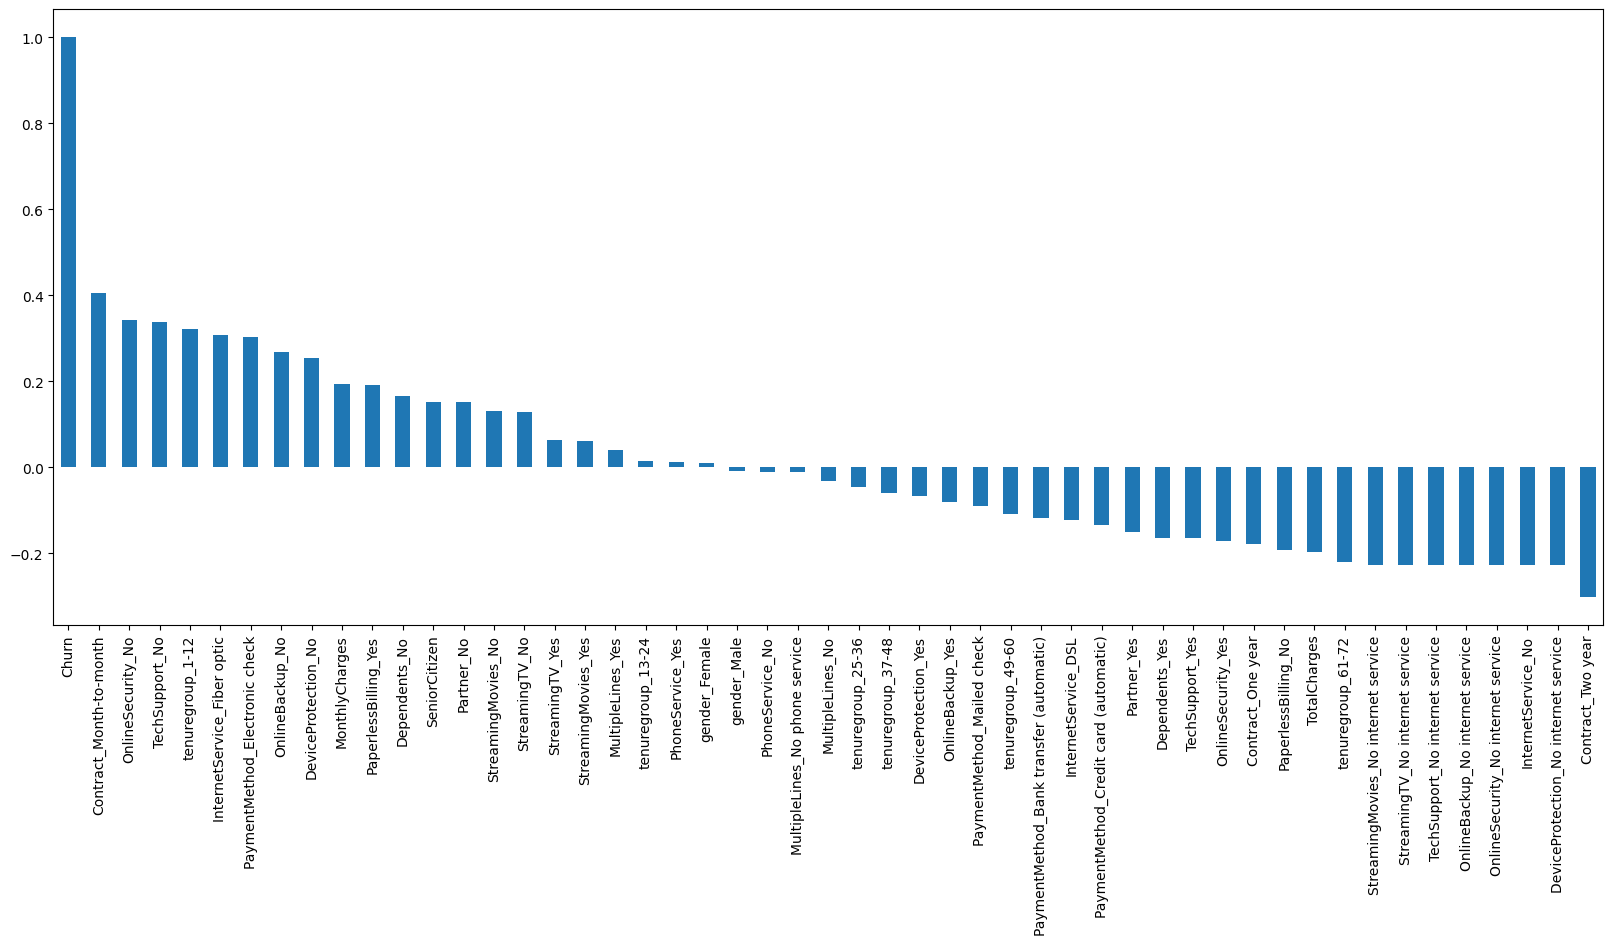

In [28]:
plt.figure(figsize=(20, 8))
df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

Derived Insight: 
HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet  
LOW Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years  
Factors like Gender, Availability of PhoneService and # of multiple lines have alomost NO impact on Churn  
This is also evident from the Heatmap below

<Axes: >

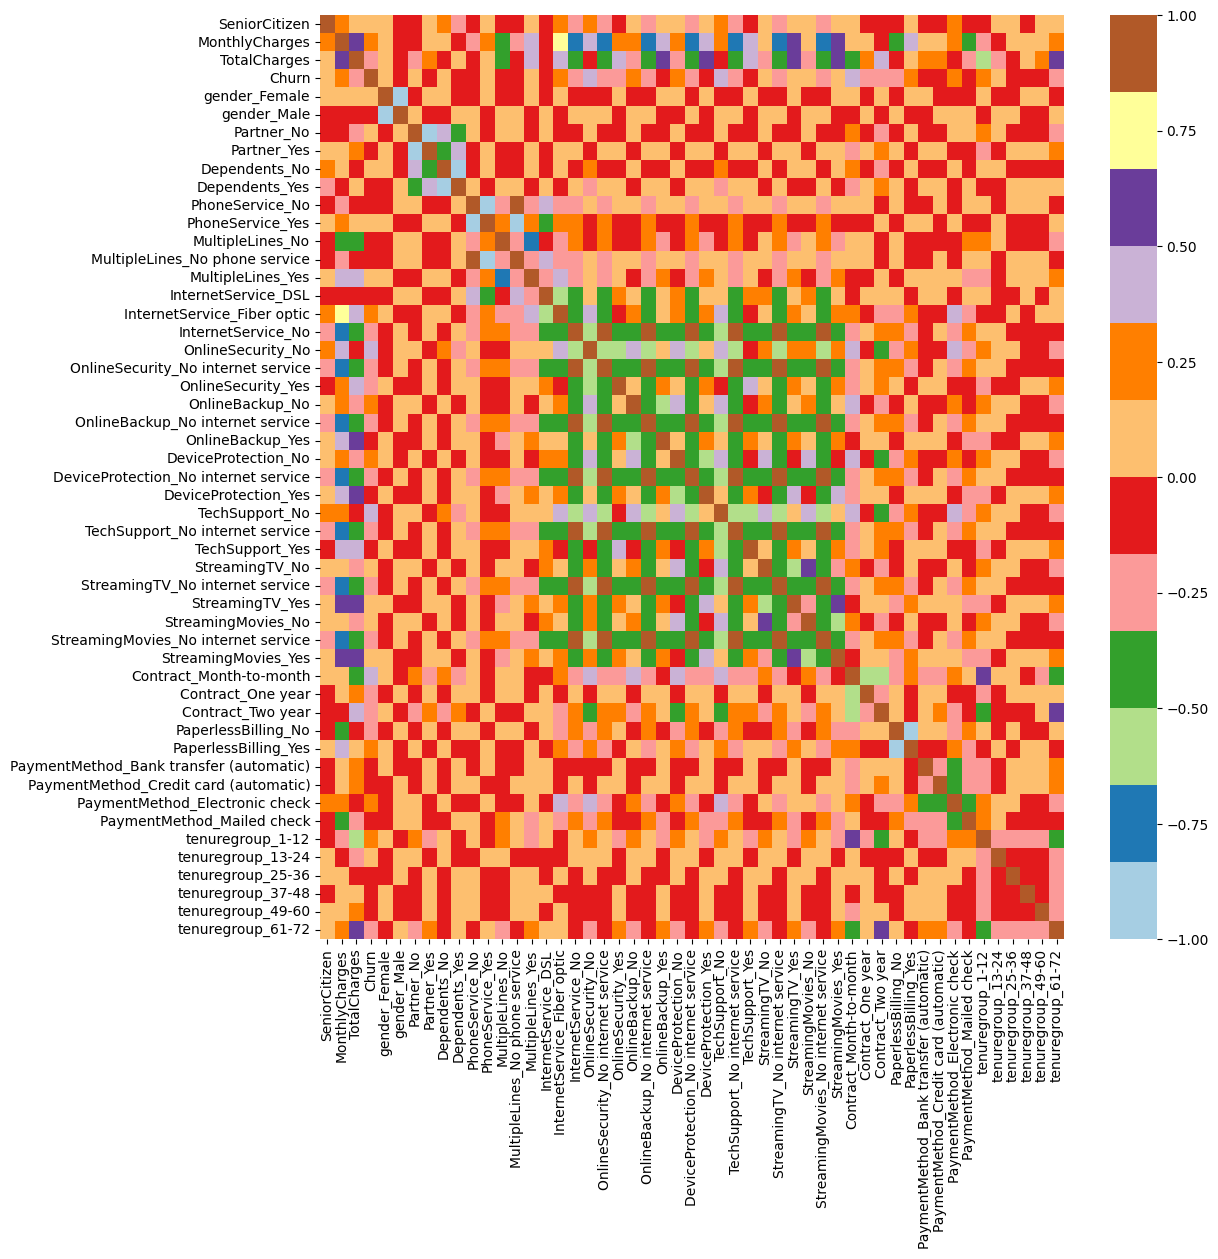

In [29]:
plt.figure(figsize=(12, 12))
sns.heatmap(df_dummies.corr(), cmap = "Paired")

**BIVARIATE ANALYSIS**

In [30]:
new_df1_target1= df.loc[df['Churn'] == 1]
new_df1_target0= df.loc[df['Churn'] == 0]
new_df1_target0

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenuregroup
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
6,Male,0,No,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,13-24
7,Female,0,No,No,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,1-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,61-72
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,13-24
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,61-72
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,1-12


In [31]:
def uniplot(df, col, title, hue=None):

    sns.set_style("whitegrid")
    sns.set_context("talk")

    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams["axes.titlesize"] = 22
    plt.rcParams["axes.titlepad"] = 30

    fig, ax = plt.subplots()

    n_categories = len(df[col].unique())

    if hue:
        n_hue = len(df[hue].unique())
        width = n_categories + 7 + 2 * n_hue
    else:
        width = n_categories + 7

    fig.set_size_inches(width, 8)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette="bright",
        ax=ax
    )

    plt.xticks(rotation=45)
    plt.yscale("log")
    plt.title(title)

    plt.show()

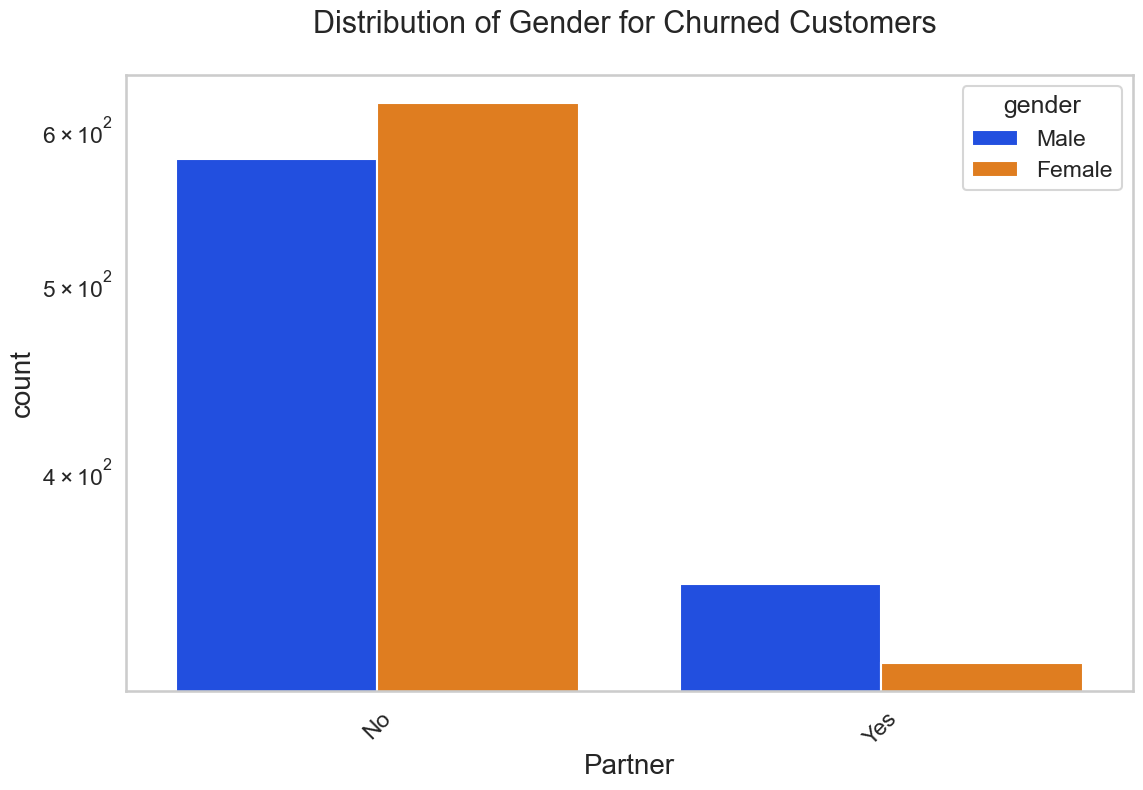

In [32]:
uniplot(new_df1_target1, 'Partner', 'Distribution of Gender for Churned Customers ', hue = 'gender')

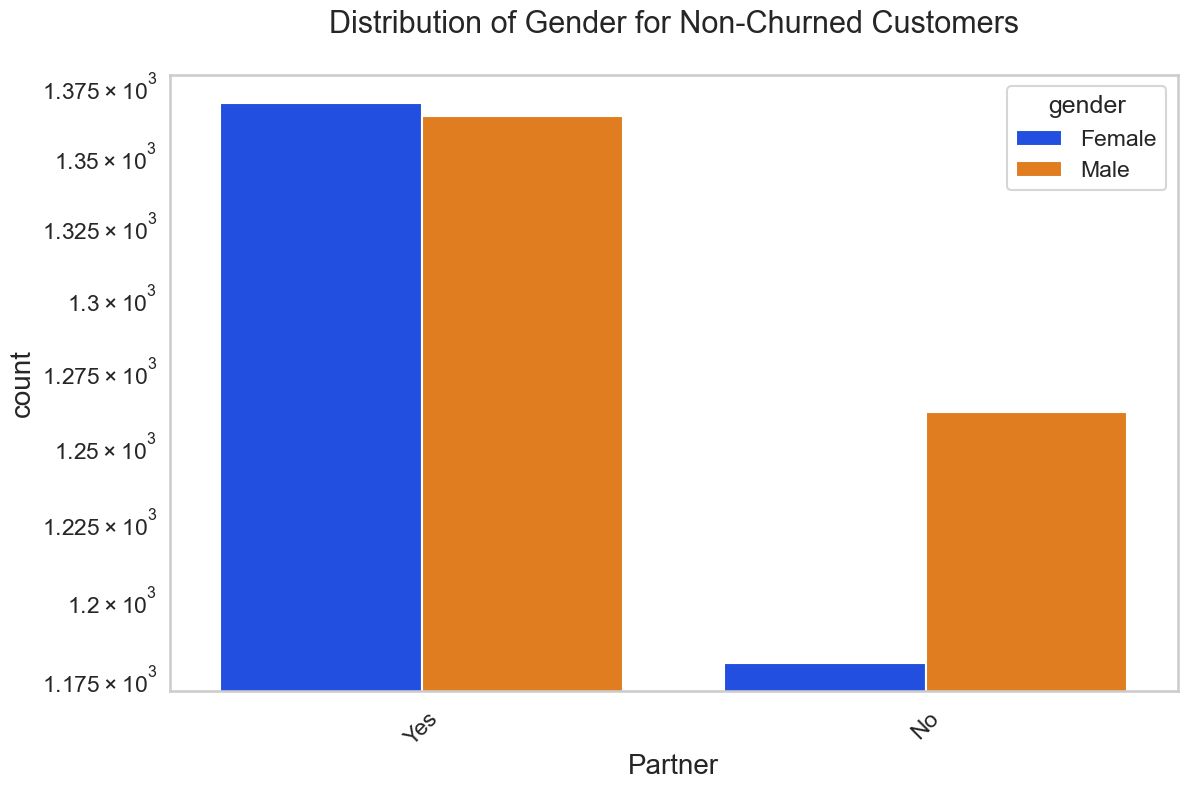

In [33]:
uniplot(new_df1_target0, 'Partner', 'Distribution of Gender for Non-Churned Customers', hue='gender')

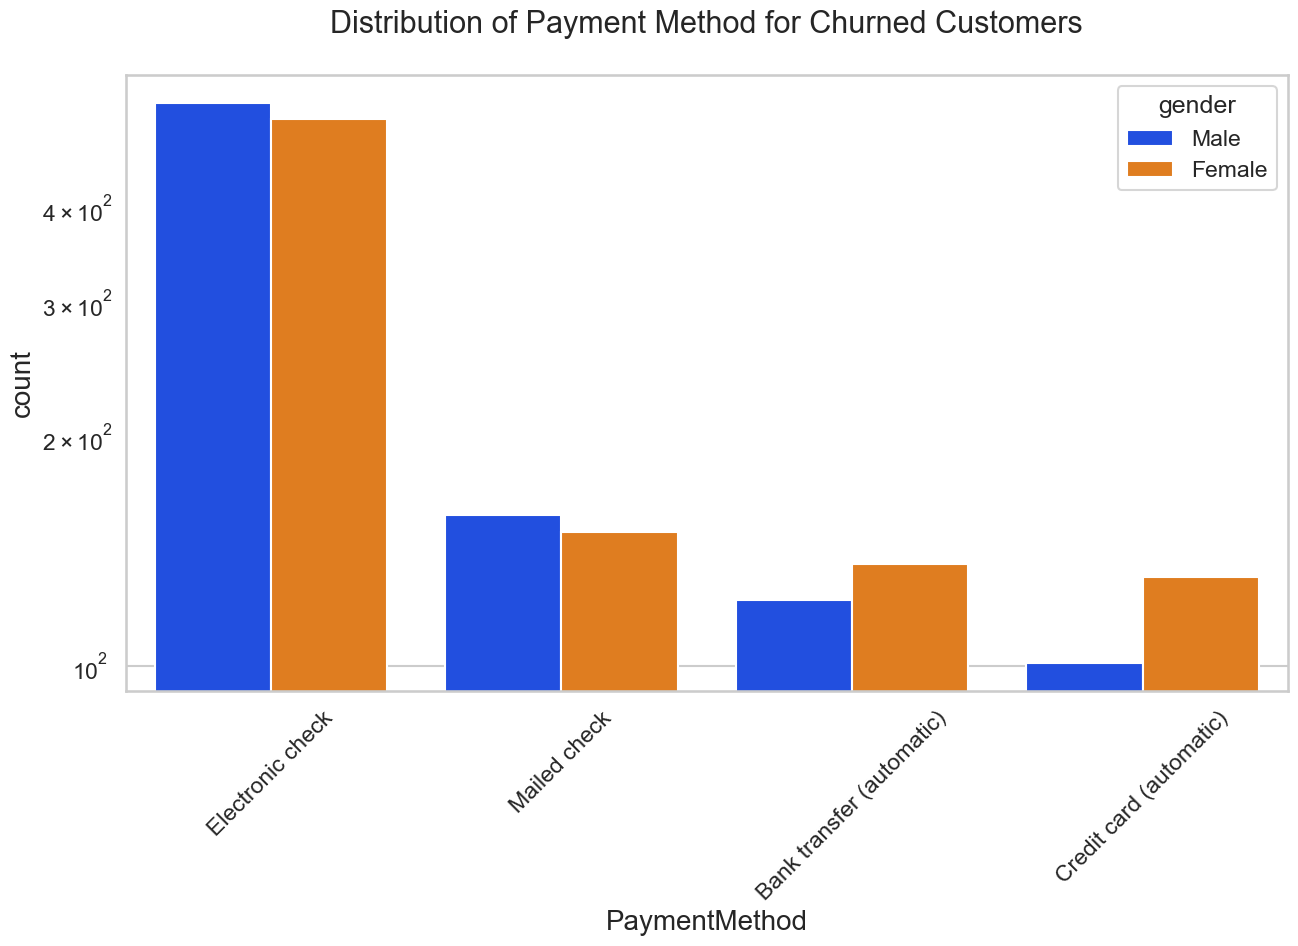

In [34]:
uniplot(new_df1_target1, 'PaymentMethod', 'Distribution of Payment Method for Churned Customers', hue='gender')

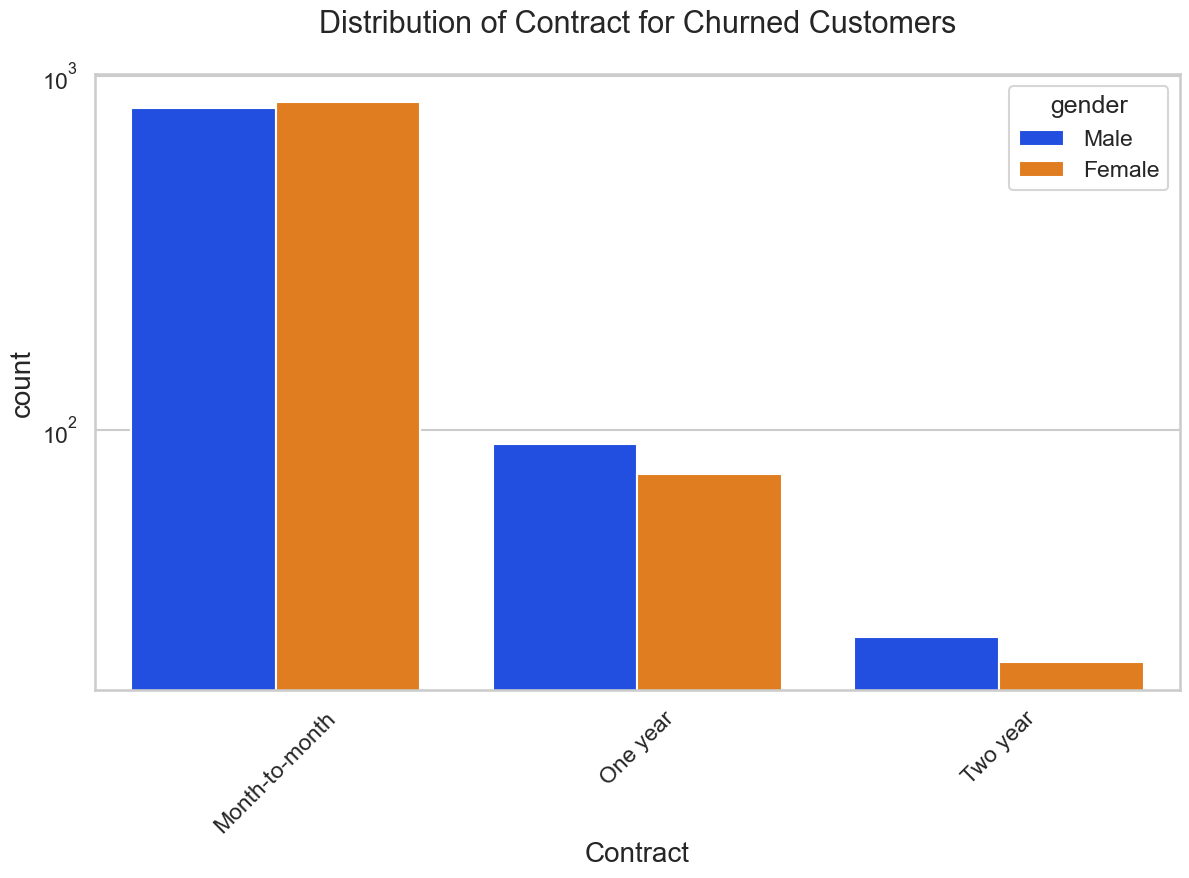

In [35]:
uniplot(new_df1_target1, 'Contract', 'Distribution of Contract for Churned Customers', hue='gender')

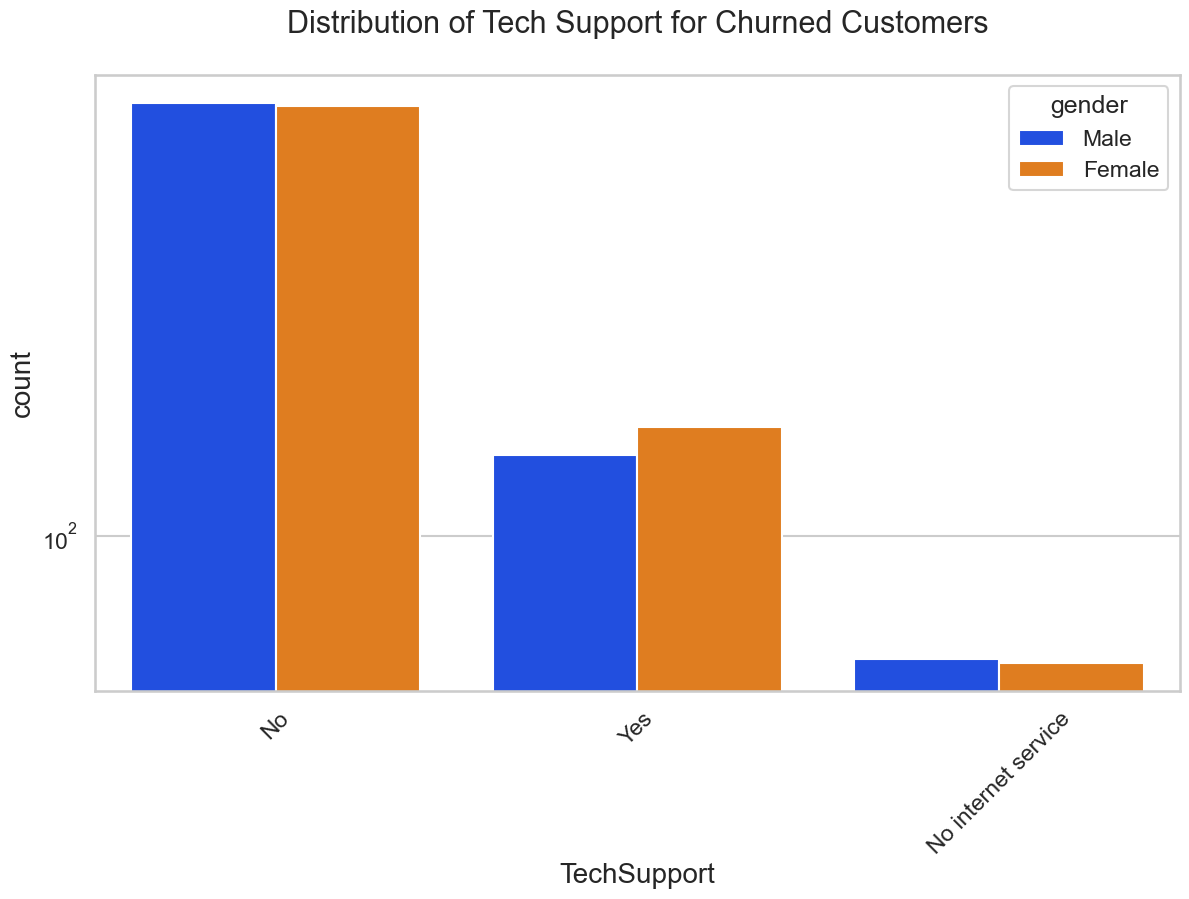

In [36]:
uniplot(new_df1_target1, 'TechSupport', 'Distribution of Tech Support for Churned Customers', hue='gender')

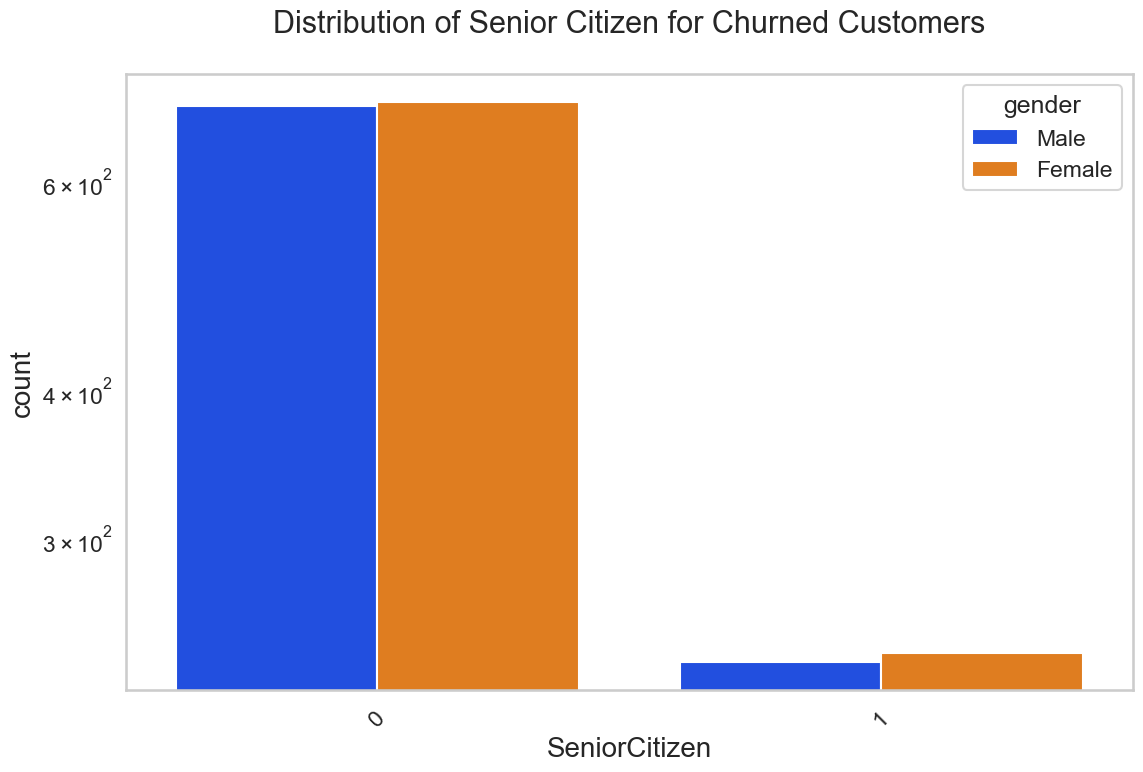

In [37]:
uniplot(new_df1_target1, 'SeniorCitizen', 'Distribution of Senior Citizen for Churned Customers', hue='gender')

**CONCLUSION**

These are some of the quick insights from this exercise:  
Electronic check medium are the highest churners  
Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.  
No Online security, No Tech Support category are high churners  
Non senior Citizens are high churners

In [38]:
df_dummies.to_csv('df_churn.csv')